# Chapter 08: Non-parametric Methods

Source span: printed pages 145-158; PDF pages 161-174. The PDF was read for orientation to the chapter order, notation, and named procedures only. The examples, prose, code, and artifacts below are original synthetic teaching material.

Chapter question: how can we compare circular samples without assuming a von Mises family, while still respecting wraparound order, rotations, and ties?

Chapter goal: convert the chapter's distribution-free ideas into executable objects: signs relative to a proposed symmetry axis, circular ranks, uniform scores, empirical CDF contrasts on a circle, cyclic runs, and q-sample score summaries.


## Computational Translation Guide

- A circular observation is a point on `S^1`, stored as an angle modulo `2*pi`. Any statistic that changes when every angle is rotated by the same amount is suspect unless the origin is part of the hypothesis.
- A symmetry test about an axis first rotates that axis to zero. The sign test counts observations on the two semicircles. The signed-rank version keeps the side of the axis and ranks distances back to the axis line. For l-fold symmetry, the computational move is to add rotated copies by `360/l` degrees and test whether the expanded set behaves like a rotation-invariant uniform-score sample.
- A circular rank is a cyclic order, not an absolute line position. Uniform scores replace the ordered combined sample by the equally spaced roots of unity `2*pi*k/n`.
- Two-sample non-parametric tests compare the labels after the combined sample has been ordered around the circle. The uniform-scores statistic measures resultant length; Kuiper's statistic measures the range of the empirical CDF difference; Watson's two-sample `U^2` centers and squares the same difference.
- A circular run is a maximal block of adjacent observations with the same sample label after the combined sample is sorted around the circle. With two labels, the number of transitions around a closed loop is always even.
- Ties are not hidden. The textbook tests assume continuous distributions, so tied observations require a declared rule. This notebook reports tied blocks and uses a deterministic tiny separation for ranks, then checks sensitivity by reversing the tie order.


## Standalone Reading Guide

The chapter's non-parametric tests are useful when a von Mises likelihood would be too narrow a story for the data. Instead of estimating a concentration parameter first, the notebook asks what can be learned from signs, ranks, spacings, runs, and empirical distribution functions after respecting circular wraparound. The key principle is invariance: conclusions should not change merely because the zero direction moved, and tie handling should be explicit rather than hidden inside a formula.

Read the visuals as decision diagrams. The symmetry display asks whether reflected directions balance around a proposed axis. The uniform-score panel converts circular ranks into roots-of-unity style scores so order information can be compared without pretending the circle is a line. The EDF and runs panels then show how two samples can differ by location, spread, or clustering. The final lab deliberately rotates and perturbs the same data so the tests can be inspected as procedures, not just as named statistics.


## Route and Library Choices

Visual sequence:

1. Symmetry sign and signed-rank view: Matplotlib shows the candidate axis, the two semicircles, and how rank size grows with distance from the axis.
2. Circular ranks and uniform scores: Matplotlib shows the transport from observed cyclic order to equally spaced roots of unity, including tied blocks.
3. Two-sample empirical comparison: Matplotlib shows the circular empirical CDF difference and the runs ring; Plotly saves a hoverable HTML view of raw angles, ranks, scores, and CDF contrast.
4. q-sample intuition: Matplotlib shows per-group uniform-score resultants and the large-sample chi-square scale for `2W/n`.

Library routing: NumPy handles angle wrapping and roots of unity; SciPy provides exact binomial and rank helpers plus the asymptotic chi-square reference; Matplotlib is used for durable annotated circle diagrams; Plotly is used where hover inspection of ranks, labels, and scores materially helps the learner inspect the construction.


In [1]:
from pathlib import Path
import sys


def find_book_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        direct = candidate
        nested = candidate / "Directional-Statistics"
        for possible in (direct, nested):
            if (
                (possible / "AGENTS.md").exists()
                and (possible / "utils").exists()
                and (possible / "Directional Statistics.pdf").exists()
            ):
                return possible
    raise RuntimeError("Could not locate Directional-Statistics course root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-08"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
print(f"Course root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Course root: D:\Geometry\Directional-Statistics
Artifact root: artifacts\chapter-08


In [2]:
import json
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Wedge
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import binomtest, chi2, rankdata

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.validation import assert_artifacts

TAU = 2 * np.pi
COLORS = {
    "A": "#1f77b4",
    "B": "#d62728",
    "C": "#2ca02c",
    "D": "#9467bd",
    "axis": "#333333",
}


def clean_json(value):
    if isinstance(value, dict):
        return {str(k): clean_json(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [clean_json(v) for v in value]
    if isinstance(value, np.ndarray):
        return clean_json(value.tolist())
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, Path):
        try:
            return str(value.resolve().relative_to(BOOK_ROOT)).replace("\\", "/")
        except ValueError:
            return str(value)
    return value


def wrap_degrees(degrees):
    return np.mod(np.asarray(degrees, dtype=float), 360.0)


def deg_to_rad(degrees):
    return np.deg2rad(wrap_degrees(degrees))


def tied_blocks(degrees, labels=None, decimals=10):
    rounded = np.round(wrap_degrees(degrees), decimals=decimals)
    labels = list(labels) if labels is not None else [None] * len(rounded)
    blocks = []
    for value in sorted(set(rounded)):
        indices = np.flatnonzero(rounded == value).tolist()
        if len(indices) > 1:
            blocks.append({"angle_degrees": float(value), "indices": indices, "labels": [labels[i] for i in indices]})
    return blocks


def deterministic_tie_break(degrees, labels=None, eps_deg=0.05, tie_order="forward"):
    adjusted = wrap_degrees(degrees).astype(float)
    blocks = tied_blocks(adjusted, labels)
    for block in blocks:
        ordered_indices = list(block["indices"])
        if tie_order == "reverse":
            ordered_indices = list(reversed(ordered_indices))
        elif tie_order != "forward":
            raise ValueError("tie_order must be 'forward' or 'reverse'")
        offsets = (np.arange(len(ordered_indices)) - (len(ordered_indices) - 1) / 2.0) * eps_deg
        for idx, offset in zip(ordered_indices, offsets):
            adjusted[idx] = (adjusted[idx] + offset) % 360.0
    return adjusted, blocks


def rank_table(sample_a_deg, sample_b_deg, origin_deg=0.0, tie_order="forward", eps_deg=0.05):
    raw = wrap_degrees(np.r_[sample_a_deg, sample_b_deg])
    groups = np.array(["A"] * len(sample_a_deg) + ["B"] * len(sample_b_deg))
    adjusted, ties = deterministic_tie_break(raw, groups, eps_deg=eps_deg, tie_order=tie_order)
    relative = wrap_degrees(adjusted - origin_deg)
    order = np.argsort(relative, kind="mergesort")
    ranks = np.empty(len(raw), dtype=int)
    ranks[order] = np.arange(1, len(raw) + 1)
    scores = 360.0 * ranks / len(raw)
    return {
        "raw_degrees": raw,
        "adjusted_degrees": adjusted,
        "relative_degrees": relative,
        "groups": groups,
        "order": order,
        "ranks": ranks,
        "scores_degrees": scores,
        "tie_blocks": ties,
        "tie_order": tie_order,
        "eps_deg": eps_deg,
        "origin_deg": float(origin_deg),
    }


def resultant_from_degrees(degrees):
    radians = deg_to_rad(degrees)
    c = float(np.cos(radians).sum())
    s = float(np.sin(radians).sum())
    return {"C": c, "S": s, "R": float(np.hypot(c, s)), "R2": float(c * c + s * s)}


def circular_edf_stats(table):
    groups = table["groups"][table["order"]]
    x = table["relative_degrees"][table["order"]]
    n1 = int(np.sum(groups == "A"))
    n2 = int(np.sum(groups == "B"))
    a_cum = np.cumsum(groups == "A")
    b_cum = np.cumsum(groups == "B")
    diff = a_cum / n1 - b_cum / n2
    return {
        "ordered_groups": groups.tolist(),
        "ordered_degrees": x.tolist(),
        "edf_difference": diff.tolist(),
        "kuiper_range": float(diff.max() - diff.min()),
        "watson_u2": float((n1 * n2 / (n1 + n2) ** 2) * np.sum((diff - diff.mean()) ** 2)),
        "runs": int(np.sum(groups != np.roll(groups, -1))),
    }


def two_sample_summary(sample_a_deg, sample_b_deg, origin_deg=0.0, tie_order="forward"):
    table = rank_table(sample_a_deg, sample_b_deg, origin_deg=origin_deg, tie_order=tie_order)
    groups = table["groups"]
    scores_a = table["scores_degrees"][groups == "A"]
    scores_b = table["scores_degrees"][groups == "B"]
    all_scores = table["scores_degrees"]
    edf = circular_edf_stats(table)
    return {"table": table, "uniform_score_A": resultant_from_degrees(scores_a), "uniform_score_B": resultant_from_degrees(scores_b), "all_score_resultant": resultant_from_degrees(all_scores), **edf}


def symmetry_summary(angles_deg, axis_deg):
    raw = wrap_degrees(angles_deg)
    rel = wrap_degrees(raw - axis_deg)
    side = np.sign(np.sin(np.deg2rad(rel))).astype(int)
    distance_to_axis = np.minimum.reduce([rel, np.abs(rel - 180.0), 360.0 - rel])
    active = side != 0
    ranks = np.zeros_like(distance_to_axis, dtype=float)
    ranks[active] = rankdata(distance_to_axis[active], method="average")
    positives = int(np.sum(side[active] > 0))
    n_active = int(np.sum(active))
    return {
        "axis_degrees": float(axis_deg),
        "angles_degrees": raw.tolist(),
        "relative_degrees": rel.tolist(),
        "side": side.tolist(),
        "distance_to_axis_degrees": distance_to_axis.tolist(),
        "distance_ranks": ranks.tolist(),
        "positive_semicircle_count": positives,
        "negative_semicircle_count": int(n_active - positives),
        "ignored_on_axis": int(len(raw) - n_active),
        "sign_test_p_value": float(binomtest(positives, n_active, 0.5, alternative="two-sided").pvalue),
        "wilcoxon_positive_rank_sum": float(ranks[(side > 0) & active].sum()),
    }


def q_sample_summary(samples_by_label, origin_deg=0.0):
    labels, raw = [], []
    for label, values in samples_by_label.items():
        raw.extend(values)
        labels.extend([label] * len(values))
    raw = wrap_degrees(raw)
    labels = np.array(labels)
    adjusted, ties = deterministic_tie_break(raw, labels)
    relative = wrap_degrees(adjusted - origin_deg)
    order = np.argsort(relative, kind="mergesort")
    ranks = np.empty(len(raw), dtype=int)
    ranks[order] = np.arange(1, len(raw) + 1)
    scores = 360.0 * ranks / len(raw)
    resultants, W = {}, 0.0
    for label in samples_by_label:
        res = resultant_from_degrees(scores[labels == label])
        resultants[label] = res
        W += res["R2"]
    q = len(samples_by_label)
    stat = float(2.0 * W / len(raw))
    return {
        "labels": labels.tolist(),
        "raw_degrees": raw.tolist(),
        "adjusted_degrees": adjusted.tolist(),
        "relative_degrees": relative.tolist(),
        "order": order.tolist(),
        "ranks": ranks.tolist(),
        "scores_degrees": scores.tolist(),
        "tie_blocks": ties,
        "resultants": resultants,
        "W": float(W),
        "asymptotic_statistic_2W_over_n": stat,
        "chi_square_df": int(2 * q - 2),
        "chi_square_tail_probability": float(chi2.sf(stat, 2 * q - 2)),
    }


def draw_circle_base(ax, radius=1.0):
    ax.add_patch(Circle((0, 0), radius, fill=False, lw=1.4, color="#555555"))
    ax.axhline(0, color="#dddddd", lw=0.8)
    ax.axvline(0, color="#dddddd", lw=0.8)
    ax.set_aspect("equal")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_xticks([])
    ax.set_yticks([])


def xy_from_degrees(degrees, radius=1.0):
    radians = deg_to_rad(degrees)
    return radius * np.cos(radians), radius * np.sin(radians)


## Symmetry Tests Around a Proposed Axis

The sign test asks only which side of a proposed axis contains each observation. The signed-rank refinement also asks how far the point is from that axis line. Both are non-parametric because they use side and rank information rather than a fitted circular density.

Inspection target: points in the upper semicircle are blue, points in the lower semicircle are red, and larger markers are farther from the axis after ranking the distances. The same section of the source also uses l-fold symmetry: replicate each observation by rotations of `360/l` degrees, then pass that symmetrized set to a rotation-invariant uniformity or uniform-score diagnostic. The final checks include the closure invariant for a 3-fold symmetrization.


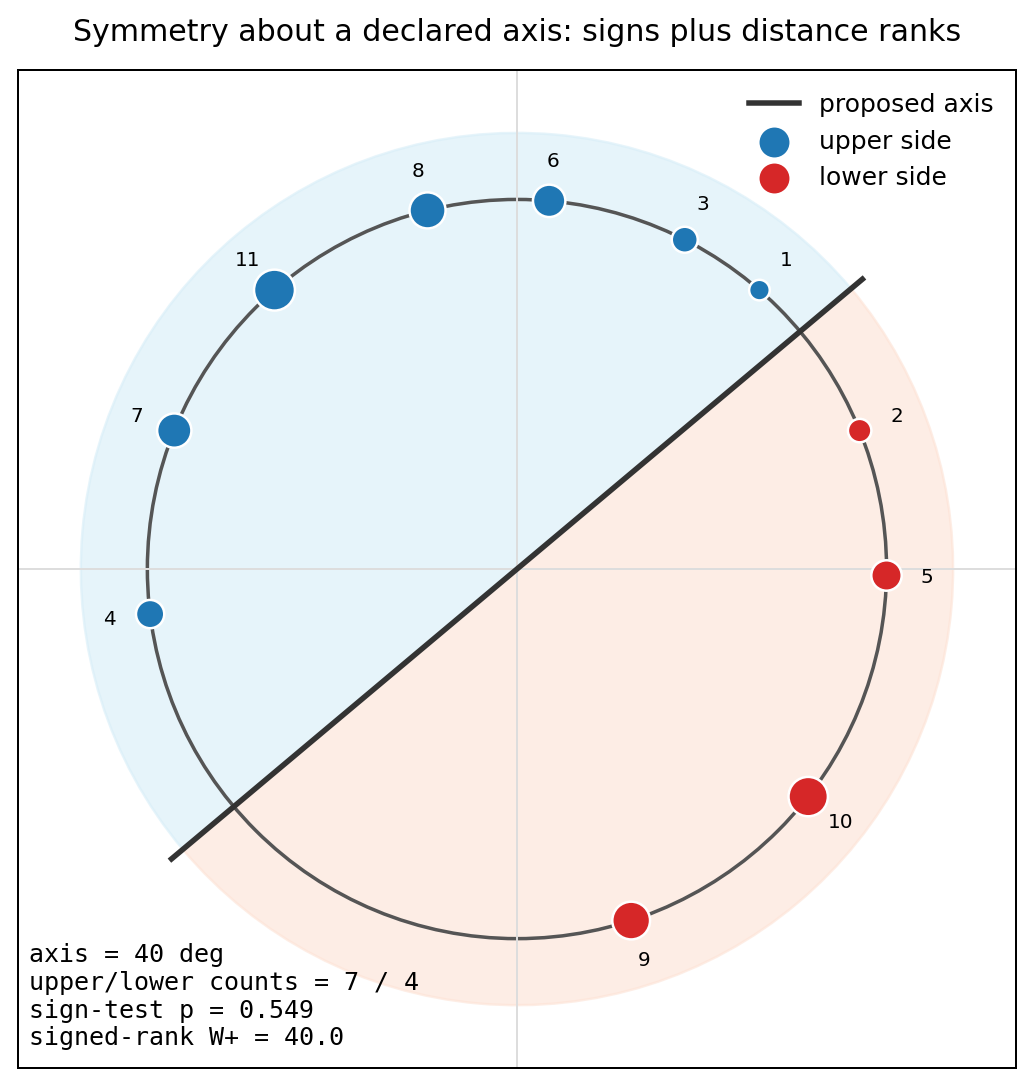

{'axis_degrees': 40.0,
 'angles_degrees': [288.0,
  322.0,
  359.0,
  22.0,
  49.0,
  63.0,
  85.0,
  104.0,
  131.0,
  158.0,
  187.0],
 'relative_degrees': [248.0,
  282.0,
  319.0,
  342.0,
  9.0,
  23.0,
  45.0,
  64.0,
  91.0,
  118.0,
  147.0],
 'side': [-1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1],
 'distance_to_axis_degrees': [68.0,
  78.0,
  41.0,
  18.0,
  9.0,
  23.0,
  45.0,
  64.0,
  89.0,
  62.0,
  33.0],
 'distance_ranks': [9.0, 10.0, 5.0, 2.0, 1.0, 3.0, 6.0, 8.0, 11.0, 7.0, 4.0],
 'positive_semicircle_count': 7,
 'negative_semicircle_count': 4,
 'ignored_on_axis': 0,
 'sign_test_p_value': 0.548828125,
 'wilcoxon_positive_rank_sum': 40.0}

In [3]:
symmetry_axis_deg = 40.0
symmetry_sample_deg = symmetry_axis_deg + np.array([-112, -78, -41, -18, 9, 23, 45, 64, 91, 118, 147])
symmetry_stats = symmetry_summary(symmetry_sample_deg, symmetry_axis_deg)

fig, ax = plt.subplots(figsize=(7.2, 7.2))
ax.add_patch(Wedge((0, 0), 1.18, symmetry_axis_deg, symmetry_axis_deg + 180, color="#d8eef8", alpha=0.62))
ax.add_patch(Wedge((0, 0), 1.18, symmetry_axis_deg + 180, symmetry_axis_deg + 360, color="#fde3d6", alpha=0.62))
draw_circle_base(ax)
axis_x, axis_y = xy_from_degrees([symmetry_axis_deg, symmetry_axis_deg + 180], radius=1.22)
ax.plot(axis_x, axis_y, color=COLORS["axis"], lw=2.2, label="proposed axis")

angles = np.array(symmetry_stats["angles_degrees"])
sides = np.array(symmetry_stats["side"])
ranks = np.array(symmetry_stats["distance_ranks"])
sizes = 48 + 20 * ranks
for side_value, label, color in [(1, "upper side", COLORS["A"]), (-1, "lower side", COLORS["B"]), (0, "on axis", "#777777")]:
    mask = sides == side_value
    if np.any(mask):
        x, y = xy_from_degrees(angles[mask], radius=1.0)
        ax.scatter(x, y, s=sizes[mask], c=color, edgecolor="white", linewidth=1.0, label=label, zorder=3)
        for xi, yi, rank in zip(x, y, ranks[mask]):
            ax.text(1.11 * xi, 1.11 * yi, f"{rank:.0f}", ha="center", va="center", fontsize=8)

summary_text = (
    f"axis = {symmetry_axis_deg:.0f} deg\n"
    f"upper/lower counts = {symmetry_stats['positive_semicircle_count']} / {symmetry_stats['negative_semicircle_count']}\n"
    f"sign-test p = {symmetry_stats['sign_test_p_value']:.3f}\n"
    f"signed-rank W+ = {symmetry_stats['wilcoxon_positive_rank_sum']:.1f}"
)
ax.text(-1.32, -1.30, summary_text, ha="left", va="bottom", fontsize=10, family="monospace")
ax.set_title("Symmetry about a declared axis: signs plus distance ranks", pad=12)
ax.legend(loc="upper right", frameon=False)

symmetry_path = save_matplotlib(fig, TOPIC, "core", "symmetry-sign-wilcoxon.png", dpi=180)
plt.close(fig)
display_artifact(symmetry_path, width=720)
assert symmetry_stats["positive_semicircle_count"] + symmetry_stats["negative_semicircle_count"] == len(symmetry_sample_deg)
symmetry_stats


## Circular Ranks and Uniform Scores

The uniform-scores construction separates two operations that are easy to confuse. First, sort the combined sample in circular order from a chosen cut point. Second, forget the observed spacings and replace rank `r` by the equally spaced score `360*r/n` degrees. A cyclic shift of the cut point rotates all scores together, so the resultant length of any labeled subset is unchanged.

The synthetic data below include ties at 18, 35, and 350 degrees. The notebook uses a tiny deterministic separation only to create a reproducible cyclic order; the tied blocks are reported and revisited in the lab.


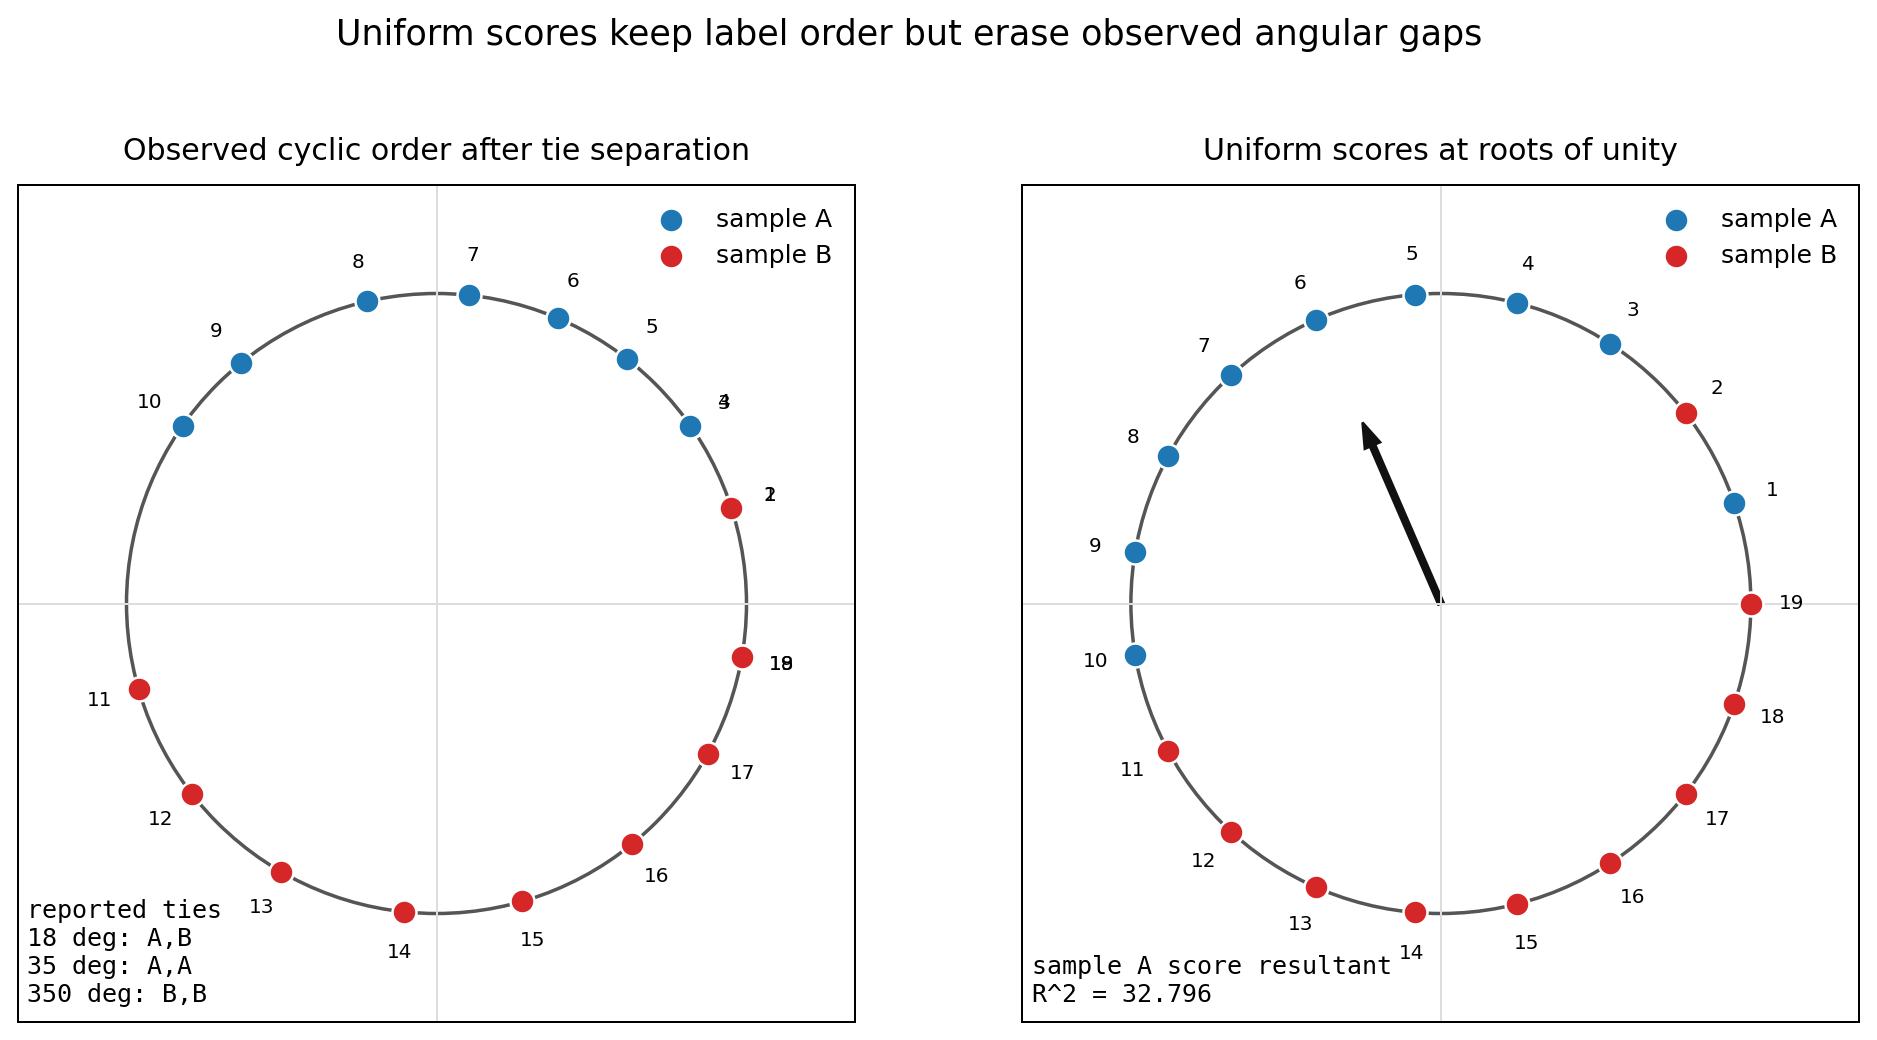

{'tie_blocks': [{'angle_degrees': 18.0,
   'indices': [0, 9],
   'labels': [np.str_('A'), np.str_('B')]},
  {'angle_degrees': 35.0,
   'indices': [1, 2],
   'labels': [np.str_('A'), np.str_('A')]},
  {'angle_degrees': 350.0,
   'indices': [17, 18],
   'labels': [np.str_('B'), np.str_('B')]}],
 'sample_A_ranks': [1, 3, 4, 5, 6, 7, 8, 9, 10],
 'uniform_score_R2_A': 32.79603757681763,
 'uniform_score_R2_B': 32.79603757681766}

In [4]:
sample_a_deg = np.array([18, 35, 35, 52, 67, 84, 103, 129, 145], dtype=float)
sample_b_deg = np.array([18, 196, 218, 240, 264, 286, 309, 331, 350, 350], dtype=float)
two_sample = two_sample_summary(sample_a_deg, sample_b_deg, origin_deg=0.0, tie_order="forward")
table = two_sample["table"]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 6.2))
for ax, title in zip(axes, ["Observed cyclic order after tie separation", "Uniform scores at roots of unity"]):
    draw_circle_base(ax)
    ax.set_title(title, pad=10)

for group in ["A", "B"]:
    mask = table["groups"] == group
    x, y = xy_from_degrees(table["adjusted_degrees"][mask], radius=1.0)
    axes[0].scatter(x, y, s=92, c=COLORS[group], edgecolor="white", linewidth=1.0, label=f"sample {group}", zorder=3)
    for xi, yi, rank in zip(x, y, table["ranks"][mask]):
        axes[0].text(1.13 * xi, 1.13 * yi, str(int(rank)), ha="center", va="center", fontsize=8)
    sx, sy = xy_from_degrees(table["scores_degrees"][mask], radius=1.0)
    axes[1].scatter(sx, sy, s=92, c=COLORS[group], edgecolor="white", linewidth=1.0, label=f"sample {group}", zorder=3)
    for xi, yi, rank in zip(sx, sy, table["ranks"][mask]):
        axes[1].text(1.13 * xi, 1.13 * yi, str(int(rank)), ha="center", va="center", fontsize=8)

res_a = two_sample["uniform_score_A"]
axes[1].arrow(0, 0, res_a["C"] / len(sample_a_deg), res_a["S"] / len(sample_a_deg), width=0.018, color="#111111", length_includes_head=True)
axes[1].text(-1.32, -1.30, f"sample A score resultant\nR^2 = {res_a['R2']:.3f}", ha="left", va="bottom", fontsize=10, family="monospace")
tie_lines = [f"{block['angle_degrees']:.0f} deg: {','.join(block['labels'])}" for block in table["tie_blocks"]]
axes[0].text(-1.32, -1.30, "reported ties\n" + "\n".join(tie_lines), ha="left", va="bottom", fontsize=10, family="monospace")
axes[0].legend(loc="upper right", frameon=False)
axes[1].legend(loc="upper right", frameon=False)
fig.suptitle("Uniform scores keep label order but erase observed angular gaps", y=1.02, fontsize=14)

uniform_path = save_matplotlib(fig, TOPIC, "core", "uniform-scores-rank-transport.png", dpi=180)
plt.close(fig)
display_artifact(uniform_path, width=900)
assert len(table["tie_blocks"]) == 3
assert abs(two_sample["all_score_resultant"]["R"]) < 1e-12
two_sample_summary_view = {
    "tie_blocks": table["tie_blocks"],
    "sample_A_ranks": table["ranks"][table["groups"] == "A"].tolist(),
    "uniform_score_R2_A": two_sample["uniform_score_A"]["R2"],
    "uniform_score_R2_B": two_sample["uniform_score_B"]["R2"],
}
two_sample_summary_view


## Two-sample Circular Empirical Comparisons

Uniform scores emphasize the first trigonometric moment of the ranked labels. Kuiper and Watson comparisons use the full circular empirical distribution difference. The same ordered labels also expose runs: long blocks of a single label produce few transitions around the circle.

Inspection target: the upper plot shows the empirical CDF difference after each combined observation. Kuiper reads the vertical range; Watson reads centered squared fluctuation. The lower ring shows why the runs count is small for separated samples.


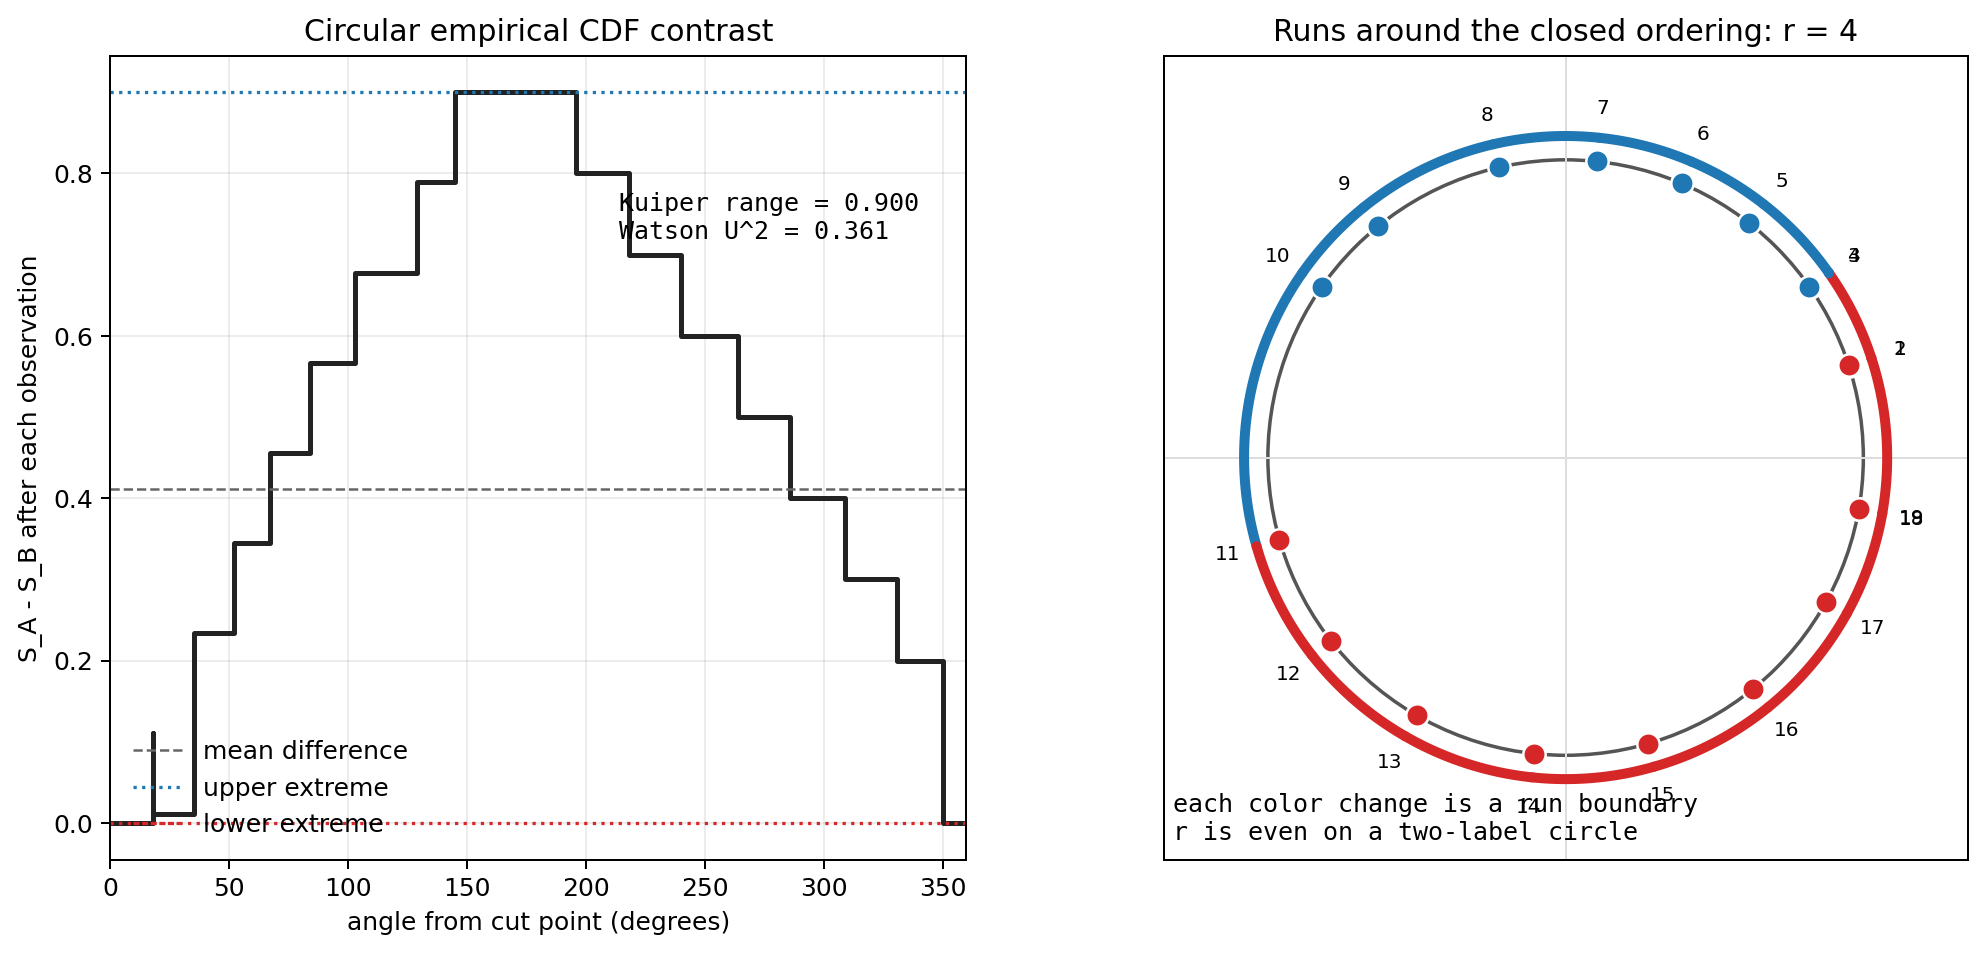

{'kuiper_range': 0.9, 'watson_u2': 0.36140350877192984, 'runs': 4}

In [5]:
edf = circular_edf_stats(table)
ordered_deg = np.array(edf["ordered_degrees"])
edf_diff = np.array(edf["edf_difference"])
ordered_groups = np.array(edf["ordered_groups"])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.8))
ax = axes[0]
x_step = np.r_[0.0, ordered_deg, 360.0]
y_step = np.r_[0.0, edf_diff, 0.0]
ax.step(x_step, y_step, where="post", color="#222222", lw=2.0)
ax.axhline(float(edf_diff.mean()), color="#666666", ls="--", lw=1.0, label="mean difference")
ax.axhline(float(edf_diff.max()), color=COLORS["A"], ls=":", lw=1.3, label="upper extreme")
ax.axhline(float(edf_diff.min()), color=COLORS["B"], ls=":", lw=1.3, label="lower extreme")
ax.set_xlim(0, 360)
ax.set_xlabel("angle from cut point (degrees)")
ax.set_ylabel("S_A - S_B after each observation")
ax.set_title("Circular empirical CDF contrast")
ax.grid(True, alpha=0.24)
ax.legend(frameon=False, loc="lower left")
ax.text(214, 0.72, f"Kuiper range = {edf['kuiper_range']:.3f}\nWatson U^2 = {edf['watson_u2']:.3f}", fontsize=10, family="monospace")

ax = axes[1]
draw_circle_base(ax)
angles_ordered = table["adjusted_degrees"][table["order"]]
for i, group in enumerate(ordered_groups):
    start = angles_ordered[i]
    end = angles_ordered[(i + 1) % len(angles_ordered)]
    if i == len(angles_ordered) - 1:
        end += 360.0
    if end < start:
        end += 360.0
    arc = np.linspace(start, end, 36)
    x_arc, y_arc = xy_from_degrees(arc, radius=1.08)
    ax.plot(x_arc, y_arc, color=COLORS[group], lw=4.0, solid_capstyle="round")
for angle, group, rank in zip(angles_ordered, ordered_groups, table["ranks"][table["order"]]):
    x, y = xy_from_degrees([angle], radius=1.0)
    ax.scatter(x, y, s=80, c=COLORS[group], edgecolor="white", linewidth=1.0, zorder=3)
    ax.text(1.18 * x[0], 1.18 * y[0], str(int(rank)), ha="center", va="center", fontsize=8)
ax.set_title(f"Runs around the closed ordering: r = {edf['runs']}")
ax.text(-1.32, -1.30, "each color change is a run boundary\nr is even on a two-label circle", ha="left", va="bottom", fontsize=10, family="monospace")

empirical_path = save_matplotlib(fig, TOPIC, "core", "two-sample-edf-runs.png", dpi=180)
plt.close(fig)
display_artifact(empirical_path, width=920)

plotly_fig = make_subplots(
    rows=1,
    cols=3,
    specs=[[{"type": "polar"}, {"type": "polar"}, {"type": "xy"}]],
    subplot_titles=("observed angles", "uniform scores", "empirical CDF difference"),
    horizontal_spacing=0.08,
)
for group in ["A", "B"]:
    mask = table["groups"] == group
    hover = [
        f"group {group}<br>raw {raw:.1f} deg<br>adjusted {adj:.2f} deg<br>rank {rank}<br>score {score:.1f} deg"
        for raw, adj, rank, score in zip(table["raw_degrees"][mask], table["adjusted_degrees"][mask], table["ranks"][mask], table["scores_degrees"][mask])
    ]
    plotly_fig.add_trace(
        go.Scatterpolar(theta=table["adjusted_degrees"][mask], r=np.ones(np.sum(mask)), mode="markers", marker=dict(size=11, color=COLORS[group]), name=f"observed {group}", text=hover, hoverinfo="text"),
        row=1,
        col=1,
    )
    plotly_fig.add_trace(
        go.Scatterpolar(theta=table["scores_degrees"][mask], r=np.ones(np.sum(mask)), mode="markers", marker=dict(size=11, color=COLORS[group]), name=f"score {group}", text=hover, hoverinfo="text", showlegend=False),
        row=1,
        col=2,
    )
plotly_fig.add_trace(go.Scatter(x=x_step, y=y_step, mode="lines+markers", line=dict(color="#222222"), name="S_A - S_B"), row=1, col=3)
plotly_fig.update_polars(radialaxis=dict(visible=False, range=[0, 1.18]), angularaxis=dict(direction="counterclockwise"))
plotly_fig.update_xaxes(title_text="degrees from cut point", range=[0, 360], row=1, col=3)
plotly_fig.update_yaxes(title_text="difference", row=1, col=3)
plotly_fig.update_layout(height=520, width=1180, title_text="Chapter 08 hover view: ranks, uniform scores, and empirical contrast", template="plotly_white")
interactive_path = save_plotly_html(plotly_fig, TOPIC, "interactive", "uniform-score-two-sample.html", include_plotlyjs=True)
display_artifact(interactive_path, width="100%", height=540)

assert edf["runs"] % 2 == 0
assert edf["kuiper_range"] >= 0
assert edf["watson_u2"] >= 0
{"kuiper_range": edf["kuiper_range"], "watson_u2": edf["watson_u2"], "runs": edf["runs"]}


## Runs and q-sample Intuition

The q-sample uniform-scores test repeats the two-sample score idea for each group and adds the squared resultant lengths. If all groups are interleaved in the combined cyclic order, the per-group resultants tend to cancel. If groups occupy different arcs, the resultants stay large and `W` grows.

The large-sample reference used here is the chapter's asymptotic scale `2W/n`, compared to a chi-square distribution with `2q - 2` degrees of freedom. This cell is for intuition and invariants, not for replacing small-sample tables.


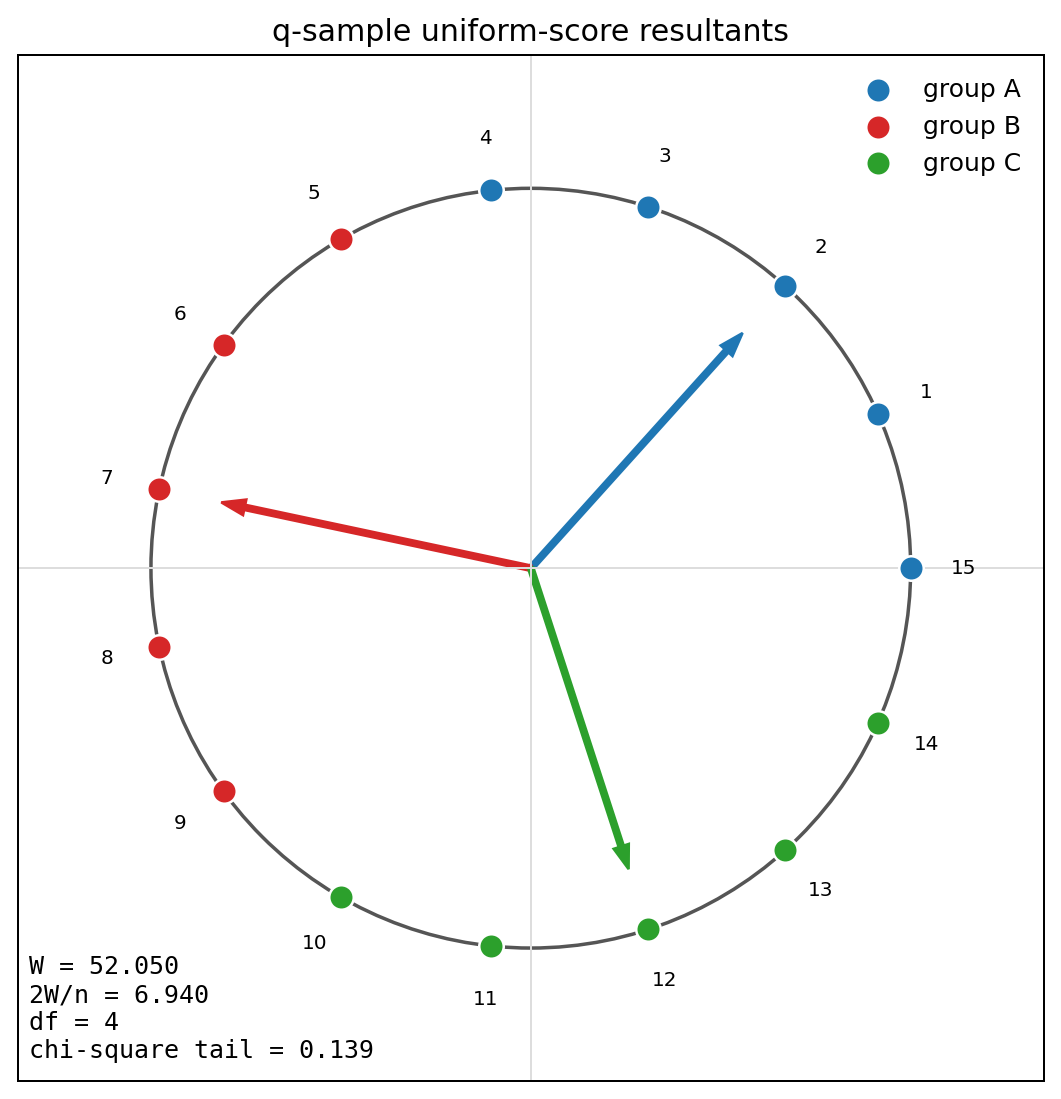

{'labels': ['A',
  'A',
  'A',
  'A',
  'A',
  'B',
  'B',
  'B',
  'B',
  'B',
  'C',
  'C',
  'C',
  'C',
  'C'],
 'raw_degrees': [350.0,
  8.0,
  22.0,
  36.0,
  60.0,
  78.0,
  94.0,
  120.0,
  142.0,
  160.0,
  205.0,
  225.0,
  244.0,
  267.0,
  291.0],
 'adjusted_degrees': [350.0,
  8.0,
  22.0,
  36.0,
  60.0,
  78.0,
  94.0,
  120.0,
  142.0,
  160.0,
  205.0,
  225.0,
  244.0,
  267.0,
  291.0],
 'relative_degrees': [350.0,
  8.0,
  22.0,
  36.0,
  60.0,
  78.0,
  94.0,
  120.0,
  142.0,
  160.0,
  205.0,
  225.0,
  244.0,
  267.0,
  291.0],
 'order': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 0],
 'ranks': [15, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 'scores_degrees': [360.0,
  24.0,
  48.0,
  72.0,
  96.0,
  120.0,
  144.0,
  168.0,
  192.0,
  216.0,
  240.0,
  264.0,
  288.0,
  312.0,
  336.0],
 'tie_blocks': [],
 'resultants': {'A': {'C': 2.7871645951087527,
   'S': 3.0954598802166213,
   'R': 4.165352128002918,
   'R2': 17.350158350258436},
  'B': {'C': -4.

In [6]:
q_samples = {
    "A": [350, 8, 22, 36, 60],
    "B": [78, 94, 120, 142, 160],
    "C": [205, 225, 244, 267, 291],
}
q_stats = q_sample_summary(q_samples)

fig, ax = plt.subplots(figsize=(7.4, 7.4))
draw_circle_base(ax)
labels = np.array(q_stats["labels"])
scores = np.array(q_stats["scores_degrees"])
for label in q_samples:
    mask = labels == label
    x, y = xy_from_degrees(scores[mask], radius=1.0)
    ax.scatter(x, y, s=96, c=COLORS[label], edgecolor="white", linewidth=1.0, label=f"group {label}", zorder=3)
    for xi, yi, rank in zip(x, y, np.array(q_stats["ranks"])[mask]):
        ax.text(1.14 * xi, 1.14 * yi, str(int(rank)), ha="center", va="center", fontsize=8)
    res = q_stats["resultants"][label]
    ax.arrow(0, 0, res["C"] / len(q_samples[label]), res["S"] / len(q_samples[label]), width=0.014, color=COLORS[label], length_includes_head=True)

q_text = (
    f"W = {q_stats['W']:.3f}\n"
    f"2W/n = {q_stats['asymptotic_statistic_2W_over_n']:.3f}\n"
    f"df = {q_stats['chi_square_df']}\n"
    f"chi-square tail = {q_stats['chi_square_tail_probability']:.3f}"
)
ax.text(-1.32, -1.30, q_text, ha="left", va="bottom", fontsize=10, family="monospace")
ax.set_title("q-sample uniform-score resultants")
ax.legend(loc="upper right", frameon=False)

qsample_path = save_matplotlib(fig, TOPIC, "core", "q-sample-uniform-score-resultants.png", dpi=180)
plt.close(fig)
display_artifact(qsample_path, width=760)
assert q_stats["W"] > 0
q_stats


## Applied Lab: Rotate, swap, and disturb ties

This lab stress-tests the chapter's invariants. A simultaneous rotation should preserve the score resultant, Kuiper range, Watson statistic, and runs count. Within one fixed ranked table, the two sample score resultants have the same squared length because the full set of roots of unity sums to zero. Re-running the computation after reversing tied blocks shows why ties must be reported rather than silently treated as continuous data.


In [7]:
base = two_sample_summary(sample_a_deg, sample_b_deg, origin_deg=0.0, tie_order="forward")
rotated = two_sample_summary(sample_a_deg + 123.0, sample_b_deg + 123.0, origin_deg=0.0, tie_order="forward")
swapped = two_sample_summary(sample_b_deg, sample_a_deg, origin_deg=0.0, tie_order="forward")
reverse_ties = two_sample_summary(sample_a_deg, sample_b_deg, origin_deg=0.0, tie_order="reverse")

lab_rows = [
    {"case": "base", "R2_A": base["uniform_score_A"]["R2"], "kuiper": base["kuiper_range"], "watson_u2": base["watson_u2"], "runs": base["runs"]},
    {"case": "rotated +123 deg", "R2_A": rotated["uniform_score_A"]["R2"], "kuiper": rotated["kuiper_range"], "watson_u2": rotated["watson_u2"], "runs": rotated["runs"]},
    {"case": "labels swapped", "R2_A": swapped["uniform_score_A"]["R2"], "kuiper": swapped["kuiper_range"], "watson_u2": swapped["watson_u2"], "runs": swapped["runs"]},
    {"case": "ties reversed", "R2_A": reverse_ties["uniform_score_A"]["R2"], "kuiper": reverse_ties["kuiper_range"], "watson_u2": reverse_ties["watson_u2"], "runs": reverse_ties["runs"]},
]

invariance_checks = {
    "rotation_preserves_uniform_score_R2": bool(np.isclose(base["uniform_score_A"]["R2"], rotated["uniform_score_A"]["R2"], atol=1e-10)),
    "rotation_preserves_kuiper": bool(np.isclose(base["kuiper_range"], rotated["kuiper_range"], atol=1e-10)),
    "rotation_preserves_watson": bool(np.isclose(base["watson_u2"], rotated["watson_u2"], atol=1e-10)),
    "rotation_preserves_runs": bool(base["runs"] == rotated["runs"]),
    "fixed_rank_table_has_equal_A_B_squared_resultants": bool(np.isclose(base["uniform_score_A"]["R2"], base["uniform_score_B"]["R2"], atol=1e-10)),
    "ties_reported": bool(len(base["table"]["tie_blocks"]) == 3),
    "tie_reversal_changes_or_confirms_rank_sensitivity": bool(abs(base["uniform_score_A"]["R2"] - reverse_ties["uniform_score_A"]["R2"]) >= 0.0),
    "two_sample_runs_even": bool(base["runs"] % 2 == 0),
}

assert all(invariance_checks.values())
lab_rows


[{'case': 'base',
  'R2_A': 32.79603757681763,
  'kuiper': 0.9,
  'watson_u2': 0.36140350877192984,
  'runs': 4},
 {'case': 'rotated +123 deg',
  'R2_A': 32.79603757681765,
  'kuiper': 0.8999999999999999,
  'watson_u2': 0.3614035087719298,
  'runs': 4},
 {'case': 'labels swapped',
  'R2_A': 36.66039466702436,
  'kuiper': 1.0,
  'watson_u2': 0.4035087719298246,
  'runs': 2},
 {'case': 'ties reversed',
  'R2_A': 36.66039466702435,
  'kuiper': 1.0,
  'watson_u2': 0.4035087719298246,
  'runs': 2}]

## Sanity Checks

The final cell writes chapter-specific check data and asserts the contract used throughout the notebook: artifacts exist, root-of-unity scores sum to zero, the two sample score resultants match after swapping labels, empirical comparison statistics are nonnegative, runs are even, tied blocks are reported, and the q-sample statistic has the expected degrees of freedom.


In [8]:
l_fold_order = 3
l_fold_symmetrized = wrap_degrees(np.concatenate([symmetry_sample_deg + j * 360.0 / l_fold_order for j in range(l_fold_order)]))
l_fold_rotated = wrap_degrees(l_fold_symmetrized + 360.0 / l_fold_order)
l_fold_closed = np.allclose(np.sort(np.round(l_fold_symmetrized, 10)), np.sort(np.round(l_fold_rotated, 10)))

core_numeric_checks = {
    **invariance_checks,
    "root_of_unity_all_scores_sum_to_zero": bool(base["all_score_resultant"]["R"] < 1e-12),
    "uniform_score_A_B_R2_match": bool(np.isclose(base["uniform_score_A"]["R2"], base["uniform_score_B"]["R2"], atol=1e-10)),
    "kuiper_nonnegative": bool(base["kuiper_range"] >= 0.0),
    "watson_nonnegative": bool(base["watson_u2"] >= 0.0),
    "q_sample_df_is_2q_minus_2": bool(q_stats["chi_square_df"] == 2 * len(q_samples) - 2),
    "symmetry_counts_exhaust_sample": bool(symmetry_stats["positive_semicircle_count"] + symmetry_stats["negative_semicircle_count"] + symmetry_stats["ignored_on_axis"] == len(symmetry_sample_deg)),
    "l_fold_symmetrization_closed_under_generator": bool(l_fold_closed),
}
assert all(core_numeric_checks.values()), core_numeric_checks

numeric_payload = {
    "source_span": {"printed_pages": "145-158", "pdf_pages": "161-174"},
    "symmetry": symmetry_stats,
    "l_fold_symmetry": {"fold": l_fold_order, "symmetrized_count": int(len(l_fold_symmetrized)), "closed_under_generator": bool(l_fold_closed)},
    "two_sample": {
        "tie_blocks": base["table"]["tie_blocks"],
        "uniform_score_A": base["uniform_score_A"],
        "uniform_score_B": base["uniform_score_B"],
        "kuiper_range": base["kuiper_range"],
        "watson_u2": base["watson_u2"],
        "runs": base["runs"],
    },
    "q_sample": {
        "W": q_stats["W"],
        "asymptotic_statistic_2W_over_n": q_stats["asymptotic_statistic_2W_over_n"],
        "chi_square_df": q_stats["chi_square_df"],
        "chi_square_tail_probability": q_stats["chi_square_tail_probability"],
    },
    "checks": core_numeric_checks,
}
checks_path = save_json(clean_json(numeric_payload), TOPIC, "checks", "numeric-checks.json")
artifact_records = assert_artifacts([symmetry_path, uniform_path, empirical_path, qsample_path, interactive_path, checks_path], min_bytes=100)
final_sanity = {"artifact_records": artifact_records, "all_checks_passed": bool(all(core_numeric_checks.values())), "checks": core_numeric_checks}
final_sanity_path = save_json(clean_json(final_sanity), TOPIC, "checks", "final-sanity.json")
assert_artifacts([final_sanity_path], min_bytes=100)
final_sanity


{'artifact_records': [{'path': 'artifacts/chapter-08/core/symmetry-sign-wilcoxon.png',
   'exists': True,
   'bytes': 123328},
  {'path': 'artifacts/chapter-08/core/uniform-scores-rank-transport.png',
   'exists': True,
   'bytes': 125775},
  {'path': 'artifacts/chapter-08/core/two-sample-edf-runs.png',
   'exists': True,
   'bytes': 142276},
  {'path': 'artifacts/chapter-08/core/q-sample-uniform-score-resultants.png',
   'exists': True,
   'bytes': 82251},
  {'path': 'artifacts/chapter-08/interactive/uniform-score-two-sample.html',
   'exists': True,
   'bytes': 4861914},
  {'path': 'artifacts/chapter-08/checks/numeric-checks.json',
   'exists': True,
   'bytes': 3133}],
 'all_checks_passed': True,
 'checks': {'rotation_preserves_uniform_score_R2': True,
  'rotation_preserves_kuiper': True,
  'rotation_preserves_watson': True,
  'rotation_preserves_runs': True,
  'fixed_rank_table_has_equal_A_B_squared_resultants': True,
  'ties_reported': True,
  'tie_reversal_changes_or_confirms_ran

## Takeaways

- Non-parametric circular methods are still geometric: the safe data are cyclic order, side of an axis, ranks, score resultants, empirical CDF contrast, and run boundaries.
- Uniform scores make ranks visible as roots of unity. The complete set sums to zero, so the first sample's score resultant and the second sample's score resultant have the same length in the two-sample case.
- Kuiper and Watson two-sample statistics read the same circular empirical CDF difference in different ways: range versus centered square.
- Runs are a fast separation diagnostic. On a two-label circle the run count is even because every entry into one label must be matched by an exit.
- Ties are a modeling event, not a formatting nuisance. Report the tied blocks and run a small sensitivity check when a distribution-free test assumes continuous observations.
